In [ ]:
#data set link: https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

In [2]:
# reading data

import pandas as pd
links=pd.read_csv("data/links.csv")
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [3]:
movies=pd.read_csv("data/movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings=pd.read_csv("data/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags=pd.read_csv("data/tags.csv")
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [6]:
df=pd.merge(movies,ratings,on='movieId')
df.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [7]:
print(movies.shape)
print(ratings.shape)
print(df.shape)


(9742, 3)
(100836, 4)
(100836, 6)


In [8]:
df = pd.merge(ratings, tags, on=['userId', 'movieId'], how='left')
df = pd.merge(df, movies, on='movieId', how='left')

df.head()

,userId,movieId,rating,timestamp_x,tag,timestamp_y,title,genres
0,1,1,4.0,964982703,NaN,NaN,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,NaN,NaN,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,NaN,NaN,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,NaN,NaN,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,NaN,NaN,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [9]:
df.shape

(102677, 8)

In [10]:
# user taste segmentation using ratings and movies

df1 = ratings.merge(movies, on="movieId")

user_genre = df.pivot_table(
    index="userId",
    columns="genres",
    values="rating",
    aggfunc="mean"
).fillna(0)

In [11]:
user_genre.head()

genres,(no genres listed),Action,Action|Adventure,Action|Adventure|Animation,Action|Adventure|Animation|Children,Action|Adventure|Animation|Children|Comedy,Action|Adventure|Animation|Children|Comedy|Fantasy,Action|Adventure|Animation|Children|Comedy|IMAX,Action|Adventure|Animation|Children|Comedy|Romance,Action|Adventure|Animation|Children|Comedy|Sci-Fi,...,Romance|Thriller,Romance|War,Romance|Western,Sci-Fi,Sci-Fi|IMAX,Sci-Fi|Thriller,Sci-Fi|Thriller|IMAX,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
3,0.0,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0


In [108]:
# checking null , n/a values

print(user_genre.isna().sum())
print(user_genre.isnull().sum())

genres
(no genres listed)                     0
Action                                 0
Action|Adventure                       0
Action|Adventure|Animation             0
Action|Adventure|Animation|Children    0
                                      ..
Sci-Fi|Thriller|IMAX                   0
Thriller                               0
War                                    0
Western                                0
cluster                                0
Length: 952, dtype: int64
genres
(no genres listed)                     0
Action                                 0
Action|Adventure                       0
Action|Adventure|Animation             0
Action|Adventure|Animation|Children    0
                                      ..
Sci-Fi|Thriller|IMAX                   0
Thriller                               0
War                                    0
Western                                0
cluster                                0
Length: 952, dtype: int64


In [15]:
# scaling the data

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X=scaler.fit_transform(user_genre)


In [23]:
# dimensionality reduction for vizualization
from sklearn.decomposition import PCA

pca=PCA(n_components=5)
X_2d=pca.fit_transform(X)

In [100]:
# for evaluation
labels_list=[]

In [101]:
# clustering using k-means

from sklearn.cluster import KMeans

k=5 # later we will find best k using elbow method
kmeans=KMeans(n_clusters=k,random_state=42)

clusters=kmeans.fit_predict(X)
labels_list.append(clusters)

In [42]:
# adding cluster labels
user_genre["cluster"] = clusters
user_genre.head()

genres,(no genres listed),Action,Action|Adventure,Action|Adventure|Animation,Action|Adventure|Animation|Children,Action|Adventure|Animation|Children|Comedy,Action|Adventure|Animation|Children|Comedy|Fantasy,Action|Adventure|Animation|Children|Comedy|IMAX,Action|Adventure|Animation|Children|Comedy|Romance,Action|Adventure|Animation|Children|Comedy|Sci-Fi,...,Romance|War,Romance|Western,Sci-Fi,Sci-Fi|IMAX,Sci-Fi|Thriller,Sci-Fi|Thriller|IMAX,Thriller,War,Western,cluster
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0,3
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,3


In [43]:
user_genre['cluster'].unique()

array([0, 3, 2, 1, 4], dtype=int32)

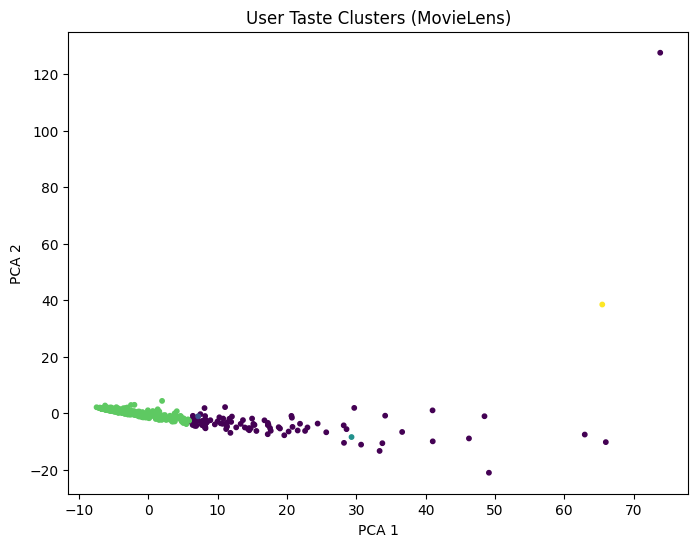

In [44]:
# vizualizing clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap="viridis", s=10)
plt.title("User Taste Clusters (MovieLens)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

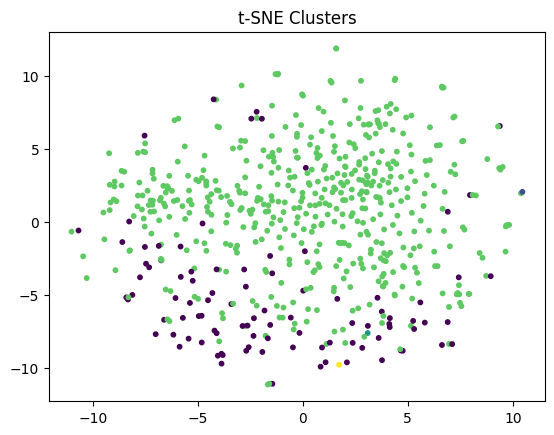

In [45]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters, cmap="viridis", s=10)
plt.title("t-SNE Clusters")
plt.show()

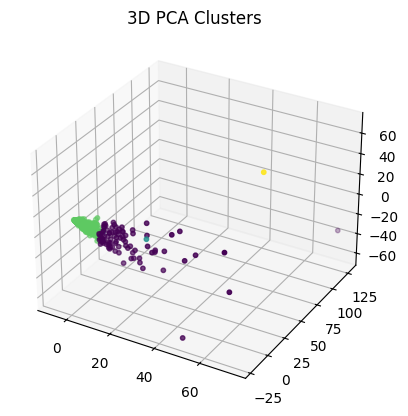

In [46]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=clusters, s=10)
plt.title("3D PCA Clusters")
plt.show()

In [47]:
cluster_profile = user_genre.groupby("cluster").mean()
#print(cluster_profile)
cluster_profile.head()

genres,(no genres listed),Action,Action|Adventure,Action|Adventure|Animation,Action|Adventure|Animation|Children,Action|Adventure|Animation|Children|Comedy,Action|Adventure|Animation|Children|Comedy|Fantasy,Action|Adventure|Animation|Children|Comedy|IMAX,Action|Adventure|Animation|Children|Comedy|Romance,Action|Adventure|Animation|Children|Comedy|Sci-Fi,...,Romance|Thriller,Romance|War,Romance|Western,Sci-Fi,Sci-Fi|IMAX,Sci-Fi|Thriller,Sci-Fi|Thriller|IMAX,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.685789,1.240123,3.372575,0.604211,0.747368,2.342982,1.105263,0.523684,0.278947,0.402632,...,0.284211,0.028947,0.124561,1.61131,1.121053,1.242732,0.426316,2.743545,0.105263,1.807544
1,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4.833333,3.250000,3.750000,0.000000,0.000000,3.875000,3.750000,0.000000,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,4.000000,4.500000,0.000000,4.500000,0.000000,0.000000
3,0.048340,0.292504,1.238851,0.059570,0.093750,0.564616,0.055664,0.055664,0.011719,0.030273,...,0.027344,0.000000,0.000000,0.21596,0.346680,0.294922,0.007812,1.481771,0.030273,0.307780
4,0.000000,3.600000,3.642857,4.166667,3.500000,4.500000,3.250000,3.500000,0.000000,0.000000,...,3.000000,0.000000,0.000000,4.00000,3.500000,0.000000,0.000000,3.666667,0.000000,4.000000


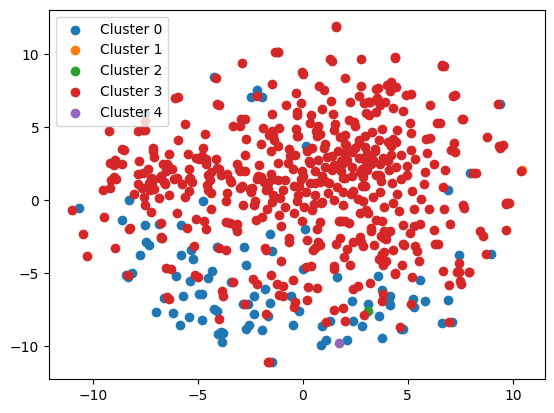

In [48]:
import numpy as np

for label in np.unique(clusters):
    X_ = X_tsne[clusters == label]
    plt.scatter(X_[:, 0], X_[:, 1], label=f"Cluster {label}")

plt.legend()
plt.show()

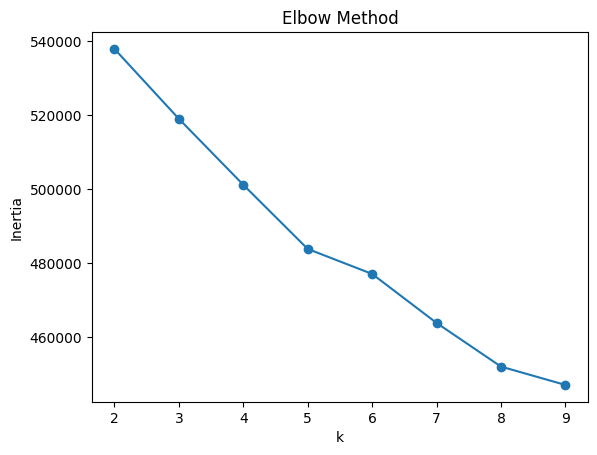

In [49]:
# finding best k using elbow method


# range of k values
k_vals = range(2, 10)

inertia = []

# compute inertia for each k
for k in k_vals:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)   # X = your feature matrix
    inertia.append(km.inertia_)

# Plot to find optimal number of clusters
plt.plot(k_vals, inertia)
plt.scatter(k_vals, inertia)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
# it seems best k is 5

In [50]:
# clustering using Mean-shift

from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
print("Estimated bandwidth:", bandwidth)

Estimated bandwidth: 28.185055046860157


In [51]:
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = ms.fit_predict(X)

In [102]:
labels_list.append(labels)

n_clusters = len(np.unique(labels))
print("Number of clusters:", n_clusters)

Number of clusters: 4


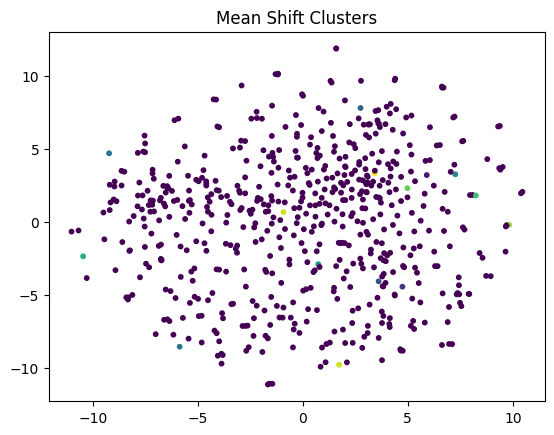

In [53]:
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis", s=10)
plt.title("Mean Shift Clusters")
plt.show()

In [90]:
# reducing dimensions using PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X)

In [103]:
# clustering using DBSCAN

from sklearn.cluster import DBSCAN

db = DBSCAN(eps=3, min_samples=5)
labels = db.fit_predict(X_reduced)

labels_list.append(labels)

In [92]:
unique_labels = np.unique(labels)
print("Clusters:", unique_labels)
print("Number of clusters:", len(unique_labels) - (1 if -1 in labels else 0))
print("Noise points:", np.sum(labels == -1))

Clusters: [-1  0  1  2]
Number of clusters: 3
Noise points: 164


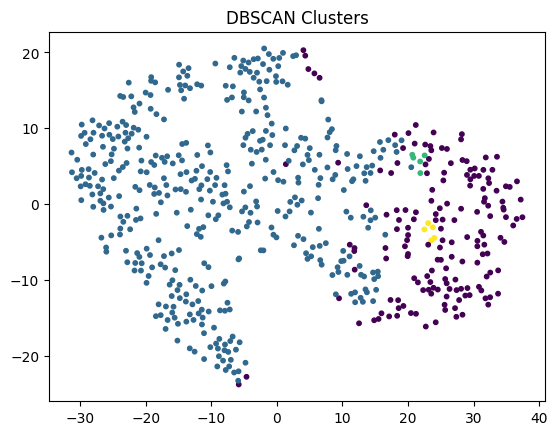

In [93]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_reduced)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis", s=10)
plt.title("DBSCAN Clusters")
plt.show()

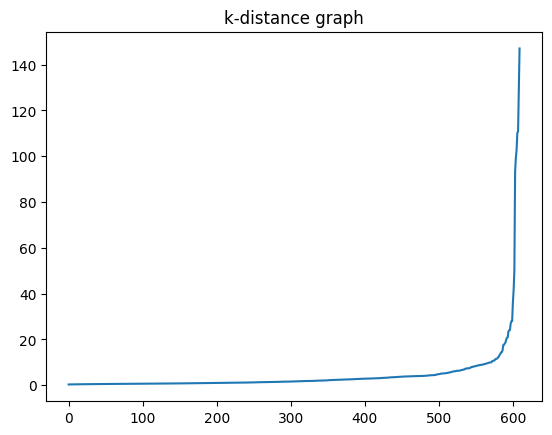

In [68]:
# finding best eps for DBSCAN

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("k-distance graph")
plt.show()

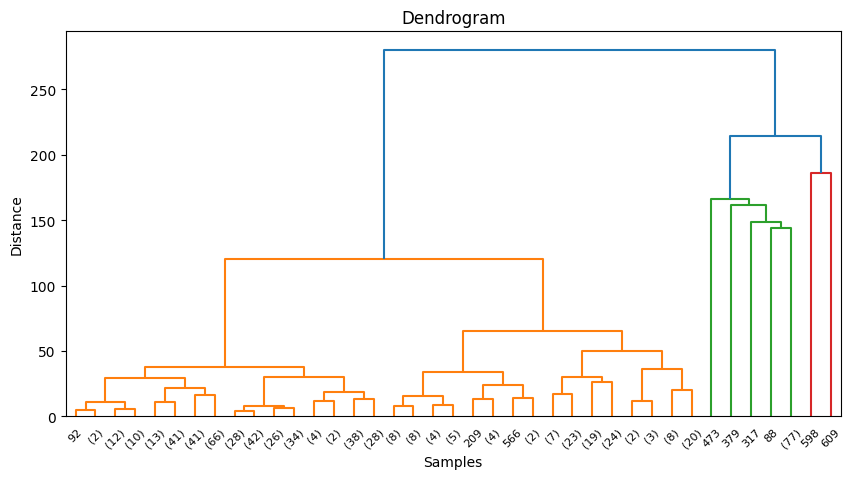

In [ ]:
# clustering using HAC

# finding best n_clusters
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_reduced, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [104]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=4,   # choose from dendrogram
    linkage='ward'
)

labels = model.fit_predict(X_reduced)

labels_list.append(labels)

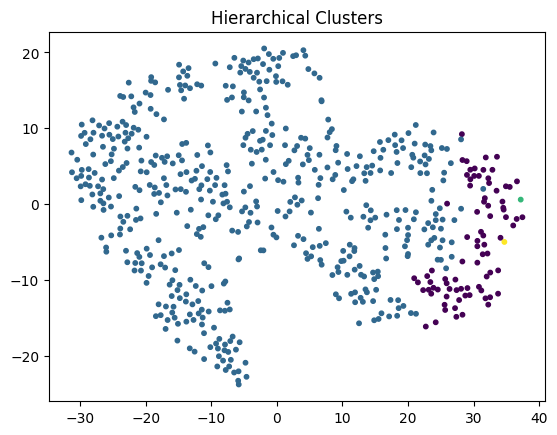

In [96]:

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_reduced)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis", s=10)
plt.title("Hierarchical Clusters")
plt.show()

What is DBI (Davies–Bouldin Index)?

The Davies–Bouldin Index (DBI) is an internal clustering evaluation metric used to measure how good your clustering is when you don’t have labels.

It answers this question:
“Are clusters compact and well-separated from each other?”

for more information about DBI: [link_1](https://en.wikipedia.org/wiki/Davies%E2%80%93Bouldin_index) , [link_2](https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/)

In [105]:
# evaluation of clustering models

from sklearn.metrics import davies_bouldin_score

algorithm=['KMeans','Mean-Shift','DBSCAN','Hierarchical Clustering']

for labels,algo in zip(labels_list,algorithm):    
    dbi = davies_bouldin_score(X, labels)
    print("DBI score for ", algo ,' is: ',dbi)

DBI score for  KMeans  is:  1.646721499749227
DBI score for  Mean-Shift  is:  1.7676436359369398
DBI score for  DBSCAN  is:  4.04470055867643
DBI score for  Hierarchical Clustering  is:  1.7676436359369398


It shows that based on dbi score K-means is the suited best for the user taste clustering